<a href="https://colab.research.google.com/github/pranathi139/GenAI/blob/main/Week1_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

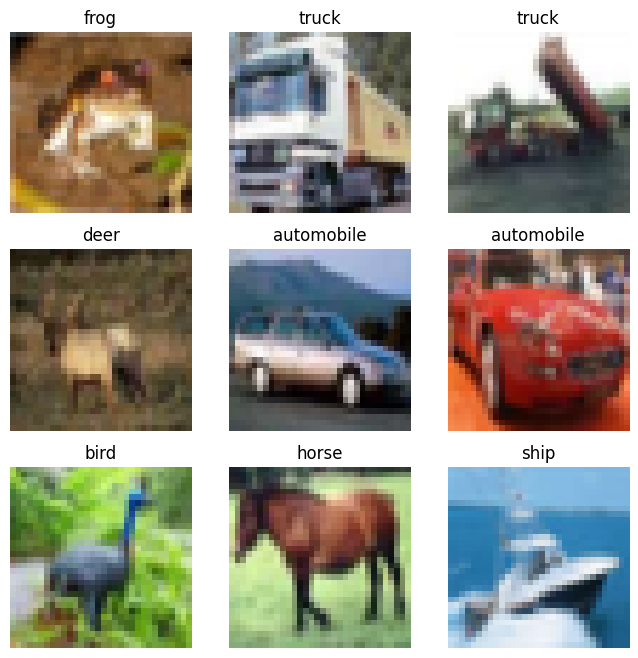

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [ ]:
model = keras.Sequential([

    # 1st Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # 2nd Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 43ms/step - accuracy: 0.4651 - loss: 1.4894 - val_accuracy: 0.5785 - val_loss: 1.2044
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6013 - loss: 1.1340 - val_accuracy: 0.6126 - val_loss: 1.1040
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6486 - loss: 1.0067 - val_accuracy: 0.6299 - val_loss: 1.0633
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6772 - loss: 0.9244 - val_accuracy: 0.6708 - val_loss: 0.9563
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.6992 - loss: 0.8617 - val_accuracy: 0.6848 - val_loss: 0.9207
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.7196 - loss: 0.8035 - val_accuracy: 0.6774 - val_loss: 0.9510
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7346 - loss: 0.7596 - val_accuracy: 0.6621 - val_loss: 0.9773
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - accuracy: 0.7510 -

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6838 - loss: 0.9744
Test Accuracy: 0.6837999820709229


In [ ]:
train_acc = history.history['accuracy'][-1]
print("Training Accuracy:", train_acc)

Training Accuracy: 0.7745599746704102


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


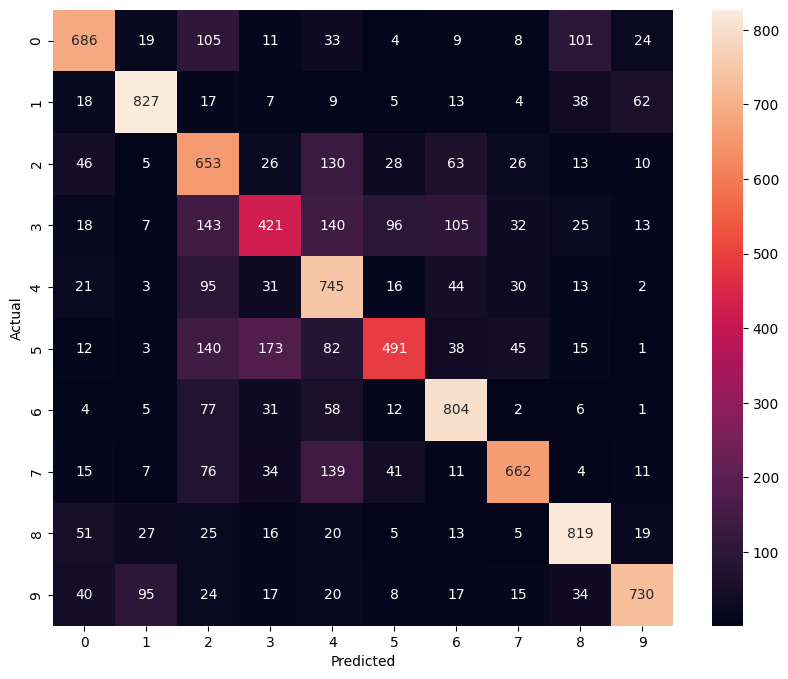

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
layers.Conv2D(64, (3,3), activation='relu')
layers.Conv2D(128, (3,3), activation='relu')

<Conv2D name=conv2d_3, built=False>

In [ ]:
layers.Dropout(0.5)

<Dropout name=dropout, built=True>

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

In [ ]:
layers.Conv2D(32, (5,5), activation='relu')

<Conv2D name=conv2d_4, built=False>